# Estimate of videos per CEO per year

In [ ]:
%pip install pandas google-api-python-client matplotlib seaborn

## Get N random CEOs

In [ ]:
import json
import pandas as pd

N = 50

with open("data/ceos_2022.json") as f:
    ceo_list = json.load(f)

available = [
    x for x in ceo_list
    if not x["videos_collected"]
]

sampled = available[:N]

sampled_ceos = pd.DataFrame(sampled)

print(sampled_ceos.to_string())

## Get interviews published in 2022

In [ ]:
import os
import json
from dotenv import load_dotenv
from googleapiclient.discovery import build

load_dotenv()

youtube = build(
    "youtube",
    "v3",
    developerKey=os.getenv("YOUTUBE_API_KEY")
)

os.makedirs("output/estimation", exist_ok=True)

# Search + get details + save everything
if len(sampled_ceos) == 0:
    print("No new CEOs left to collect.")
else:
    for _, row in sampled_ceos.iterrows():
        ceo = row["CEO"]

        search_response = youtube.search().list(
            part="snippet",
            q=f"{ceo} interview",
            type="video",
            publishedAfter="2022-01-01T00:00:00Z",
            publishedBefore="2023-01-01T00:00:00Z",
            maxResults=50
        ).execute()

        video_ids = [
            item["id"]["videoId"]
            for item in search_response["items"]
        ]

        details_response = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=",".join(video_ids)
        ).execute()

        output = {
            "ceo": ceo,
            "search_results": search_response,
            "video_details": details_response
        }

        with open(f"output/estimation/{ceo}.json", "w") as f:
            json.dump(output, f, indent=2)


        # Update ceos_2022.json immediately after success
        with open("ceos_2022.json") as f:
            ceo_list = json.load(f)

        for c in ceo_list:
            if c["CEO"] == ceo:
                c["videos_collected"] = True
                break

        with open("ceos_2022.json", "w") as f:
            json.dump(ceo_list, f, indent=2)

        print(f"Completed: {ceo}")

## Statistics

In [57]:
import os
import json

folder = "output/estimation"
num_files = 0
total_videos = 0

for file in os.listdir(folder):
    if file.endswith(".json"):
        num_files += 1

        with open(os.path.join(folder, file)) as f:
            data = json.load(f)

        total_videos += len(data["video_details"]["items"])

print("Number of CEOs:", num_files)
print("Total videos collected:", total_videos)

Number of CEOs: 93
Total videos collected: 3163


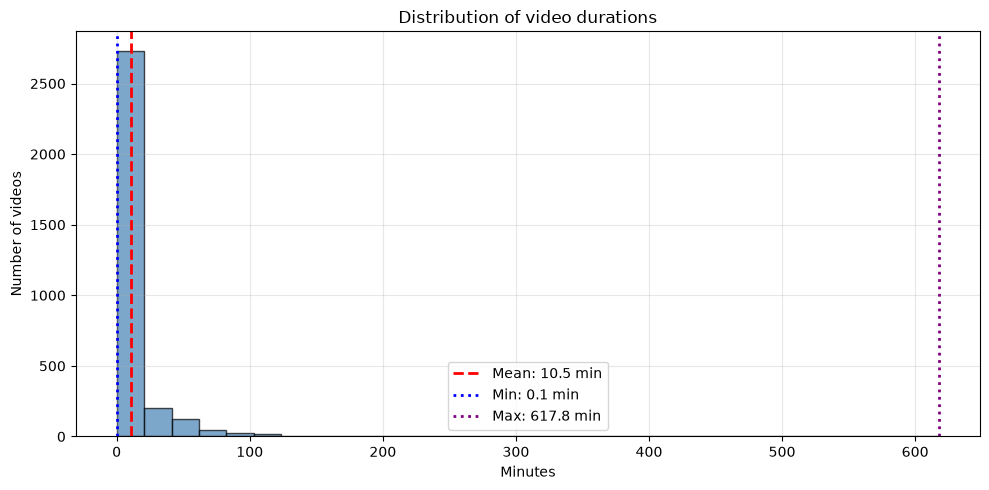

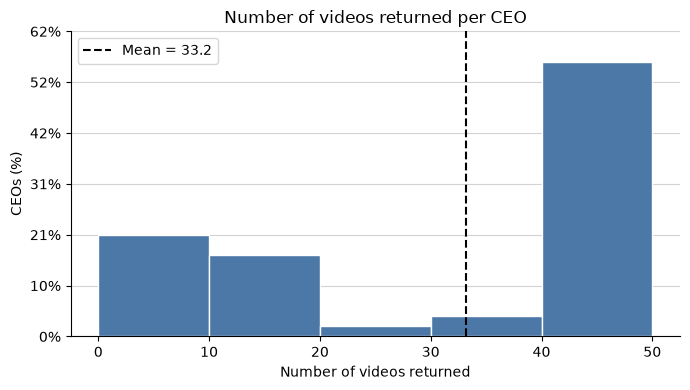

In [73]:
import os
import json
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def duration_to_seconds(duration):
    hours = re.search(r"(\d+)H", duration)
    minutes = re.search(r"(\d+)M", duration)
    seconds = re.search(r"(\d+)S", duration)

    return (
        (int(hours.group(1)) * 3600 if hours else 0) +
        (int(minutes.group(1)) * 60 if minutes else 0) +
        (int(seconds.group(1)) if seconds else 0)
    )

# collect individual video durations
all_durations = []

for file in os.listdir("output/estimation"):
    if file.endswith(".json"):
        with open(f"output/estimation/{file}") as f:
            data = json.load(f)

        for video in data["video_details"]["items"]:
            duration = duration_to_seconds(video["contentDetails"]["duration"]) / 60
            all_durations.append(duration)

# Plot 1: video duration
mean_duration = np.mean(all_durations)
min_duration = np.min(all_durations)
max_duration = np.max(all_durations)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(all_durations, bins=30, edgecolor='black', alpha=0.7, color='steelblue')

ax.axvline(mean_duration, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_duration:.1f} min')
ax.axvline(min_duration, color='blue', linestyle=':', linewidth=2, label=f'Min: {min_duration:.1f} min')
ax.axvline(max_duration, color='purple', linestyle=':', linewidth=2, label=f'Max: {max_duration:.1f} min')

ax.set_xlabel('Minutes')
ax.set_ylabel('Number of videos')
ax.set_title('Distribution of video durations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: number of videos per CEO
plt.figure(figsize=(7, 4))
counts, bins, patches = plt.hist(
    video_counts,
    bins=range(0, max(video_counts) + 5, 10),
    color="#4c78a8",
    edgecolor="white"
)
total = len(video_counts)
plt.gca().set_yticks(
    plt.gca().get_yticks()
)
plt.gca().set_yticklabels(
    [f"{y/total*100:.0f}%" for y in plt.gca().get_yticks()]
)
plt.axvline(
    np.mean(video_counts),
    color="black",
    linestyle="--",
    label=f"Mean = {np.mean(video_counts):.1f}"
)
plt.xlabel("Number of videos returned")
plt.ylabel("CEOs (%)")
plt.title("Number of videos returned per CEO")
ax = plt.gca()
ax.set_axisbelow(True)
plt.grid(
    axis="y",
    color="lightgrey",
    linewidth=0.8
)
plt.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()